#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле [taxi.csv](https://code.s3.yandex.net/datasets/taxi.csv). Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).


<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Настройка-рабочей-среды" data-toc-modified-id="Настройка-рабочей-среды-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Настройка рабочей среды</a></span><ul class="toc-item"><li><span><a href="#Установка-и-импорт-библиотек" data-toc-modified-id="Установка-и-импорт-библиотек-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Установка и импорт библиотек</a></span></li><li><span><a href="#Объявление-функций" data-toc-modified-id="Объявление-функций-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Объявление функций</a></span></li></ul></li><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Пайплайн" data-toc-modified-id="Пайплайн-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Пайплайн</a></span></li><li><span><a href="#Обучение-моделей-регрессии" data-toc-modified-id="Обучение-моделей-регрессии-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Обучение моделей регрессии</a></span></li><li><span><a href="#Выбор-лучшей-модели" data-toc-modified-id="Выбор-лучшей-модели-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Выбор лучшей модели</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

## Настройка рабочей среды

### Установка и импорт библиотек

In [1]:
# Импорт библиотек
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Устанавливаем стиль графиков
sns.set(style="whitegrid")
pd.set_option('display.max_colwidth', None)

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor

from time import time

In [2]:
# Константы
RANDOM_STATE = 42
TEST_SIZE = 0.1
RMSE_THRESHOLD = 48

### Объявление функций

In [3]:
def load_csv(file_path, file_url=None, date_columns=None, index_column=None):
    """
    Загружает данные из локального CSV файла или по URL.

    Функция проверяет, существует ли файл по указанному пути. 
    Если файл существует, данные загружаются из него. 
    В противном случае данные загружаются по указанному URL, если он предоставлен.

    Параметры:
    file_path (str): Путь к локальному файлу CSV.
    file_url (str, optional): URL для загрузки данных, если файл не найден.
    date_columns (list, optional): Список имен столбцов для преобразования в даты.
    index_column (str, int, optional): Имя или индекс столбца, который будет использоваться в качестве индекса.

    Возвращает:
    DataFrame или None: Загруженные данные в формате DataFrame, или None в случае ошибки.
    """
    try:
        # Проверяем, существует ли файл по указанному пути
        if os.path.exists(file_path):
            return pd.read_csv(file_path, parse_dates=date_columns, index_col=index_column)
        elif file_url:
            # Загружаем данные из URL, если файл не найден
            return pd.read_csv(file_url, parse_dates=date_columns, index_col=index_column)
        else:
            print("File not found and no URL provided.")
            return None
    except Exception as e:
        # В случае ошибки выводим сообщение
        print("Something went wrong:", e)
        return None

In [4]:
# Создаем функцию для вывода общей информации о датасете
def df_info(data):
    """
    Эта функция выводит общую информацию о переданном датасете, включая:
    1. Первые 5 строк для предварительного просмотра.
    2. Общую информацию о типах данных и количестве ненулевых значений.
    3. Статистику по колонкам, включая описательные статистики.
    4. Долю пропусков в каждом столбце.
    5. Количество полных дубликатов в датасете.
    
    Параметры:
    data : pd.DataFrame
        Датасет, для которого нужно вывести информацию.
    """
    
    # 1. Выводим первые 5 строк датасета для предварительного просмотра
    print(f'1. Первые 5 строк датасета:')
    display(data.head())
          
    # 2. Выводим общую информацию о датасете
    print('\n2. Общая информация о датасете:')
    print(data.info())
    
    # 3. Выводим статистику по колонкам
    print('\n3. Статистика по колонкам:')
    display(data.describe(include='all', datetime_is_numeric=True))
    
    # 4. Вычисляем и отображаем долю пропусков в колонках
    print('\n4. Доля пропусков в колонках:')
    missing_data = pd.DataFrame(round(data.isna().mean() * 100, 4).sort_values())
    display(missing_data.style.background_gradient('coolwarm'))
    
    # 5. Подсчитываем и выводим количество полных дубликатов
    print('\n5. Количество полных дубликатов:', data.duplicated().sum())

In [5]:
def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    
    # Рисуем график остатков
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.residplot(x=y_pred, y=residuals, lowess=True, color="b")
    
    # Добавляем вертикальные линии для среднего и медианы остатков
    plt.axhline(y=residuals.mean(), color='r', linestyle='--', label='Среднее остатков')
    plt.axhline(y=residuals.median(), color='r', linestyle='-', label='Медиана остатков')
    
    plt.title('График остатков')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.legend()
    plt.grid(True)
    
    # Рисуем гистограмму остатков
    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True, color="b")
    
    # Добавляем вертикальные линии для среднего и медианы остатков
    plt.axvline(x=residuals.mean(), color='r', linestyle='-', label='Среднее остатков')
    plt.axvline(x=residuals.median(), color='r', linestyle='--', label='Медиана остатков')
    
    plt.title('Гистограмма остатков')
    plt.xlabel('Остатки')
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


## Подготовка

In [6]:
taxi_path = '/datasets/taxi.csv'
taxi_url = 'https://code.s3.yandex.net/datasets/taxi.csv'

taxi = load_csv(taxi_path, taxi_url, date_columns=['datetime'], index_column='datetime')

In [7]:
# Общая информация о taxi
df_info(taxi)

1. Первые 5 строк датасета:


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None

3. Статистика по колонкам:


,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000



4. Доля пропусков в колонках:


,0
num_orders,0.000000



5. Количество полных дубликатов: 26415


- Датафрейм содержит данные о заказах такси с интервалом 10 минут.
- Пропуски отсутствуют
- Полные дубликаты не являются дубликатами, т.к. мы анализируем временные ряды и это реальные данные за разный временной период.
- Датафрейм содержит только информацию о дате и целевом признаке.
- Датафрейм включает 26496 записей о количестве поездок за период **март-август 2018 года**
- Среднее количество поездок с временным интервалом 10 минут составляет 14 шт. (мин=0, макс=119)

## Анализ

Поскольку нам предстоит спрогнозировать количество заказов такси на следующий час, то сделуем ресеплинг выборки для указанного временного интервала (1 час).


In [8]:
# проверим являются ли данные о поездках монотонными
taxi.index.is_monotonic

True

In [9]:
print(taxi.index.min())
print(taxi.index.max())

2018-03-01 00:00:00
2018-08-31 23:50:00


Данные монотонные и упорядочены по возрастанию, с ними можно работать. 

In [10]:
# сделаем ресемлинг с интервалом 1 час
df = taxi.resample('1H').sum()

In [11]:
# добавим скользящее среднее за последние сутки
df['rolling_mean'] = df['num_orders'].rolling(24).mean()
df['rolling_std'] = df['num_orders'].rolling(24).std()

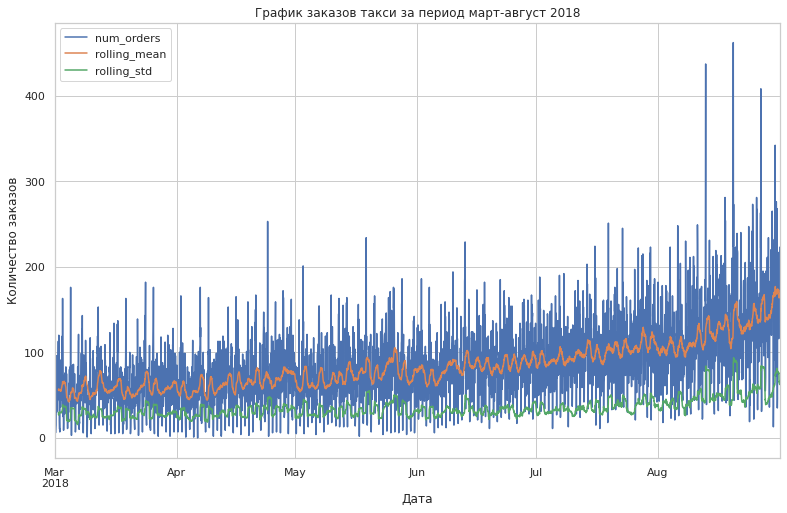

In [12]:
# построим график
df.plot(figsize=(13,8))
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('График заказов такси за период март-август 2018')
plt.legend()
plt.show()

Временной ряд нестационарный, скользящие среднее и стандартное отклонение имеют выраженную тенденцию к величению со временем.

Попробуем выделить тренд и сезонность в имещихся данных.

In [13]:
# код ревьювера
from statsmodels.tsa.stattools import adfuller

taxi = pd.read_csv("/datasets/taxi.csv", index_col=[0], parse_dates=[0]).resample('1H').sum()

ts = taxi['num_orders']
st_test = adfuller(ts, regression='ctt')

print('Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный')
if st_test[1] < 0.05:
    print('Наш ряд стационарный')
else:
    print('Ряд нестационарный')




Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный
Наш ряд стационарный


In [14]:
df

,num_orders,rolling_mean,rolling_std
datetime,,,
2018-03-01 00:00:00,124,NaN,NaN
2018-03-01 01:00:00,85,NaN,NaN
2018-03-01 02:00:00,71,NaN,NaN
2018-03-01 03:00:00,66,NaN,NaN
2018-03-01 04:00:00,43,NaN,NaN
...,...,...,...
2018-08-31 19:00:00,136,167.541667,63.268908
2018-08-31 20:00:00,154,168.041667,63.105487
2018-08-31 21:00:00,159,166.416667,62.801908


In [15]:
decomposed = seasonal_decompose(df['num_orders'])

In [16]:
def plot_decomposition(decomposed, figsize=(10, 12), titles=None, xlabel='Time', ylabel='Value', time=None, show_plots=[1, 2, 3]):
    """
    Строит графики тренда, сезонности и остатков.

    Parameters:
    decomposed: объект разложения (например, результат seasonal_decompose)
    figsize: кортеж для настройки размера фигуры
    titles: список заголовков для графиков
    xlabel: заголовок для оси X
    ylabel: заголовок для оси Y
    time: кортеж для задания диапазона по оси X (например, (start, end))
    show_plots: список номеров графиков для отображения (1: тренд, 2: сезонность, 3: остатки)
    """
    plt.figure(figsize=figsize)

    # График тренда
    if 1 in show_plots:
        plt.subplot(311)
        if time:
            decomposed.trend[time[0]:time[1]].plot(ax=plt.gca(), color='blue', linewidth=2)
        else:
            decomposed.trend.plot(ax=plt.gca(), color='blue', linewidth=2)
        plt.title(titles[0] if titles and len(titles) > 0 else 'Trend', fontsize=16)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True)

    # График сезонности
    if 2 in show_plots:
        plt.subplot(312)
        if time:
            decomposed.seasonal[time[0]:time[1]].plot(ax=plt.gca(), color='orange', linewidth=2)
        else:
            decomposed.seasonal.plot(ax=plt.gca(), color='orange', linewidth=2)
        plt.title(titles[1] if titles and len(titles) > 1 else 'Seasonality', fontsize=16)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True)

    # График остатков
    if 3 in show_plots:
        plt.subplot(313)
        if time:
            decomposed.resid[time[0]:time[1]].plot(ax=plt.gca(), color='green', linewidth=2)
        else:
            decomposed.resid.plot(ax=plt.gca(), color='green', linewidth=2)
        plt.title(titles[2] if titles and len(titles) > 2 else 'Residuals', fontsize=16)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

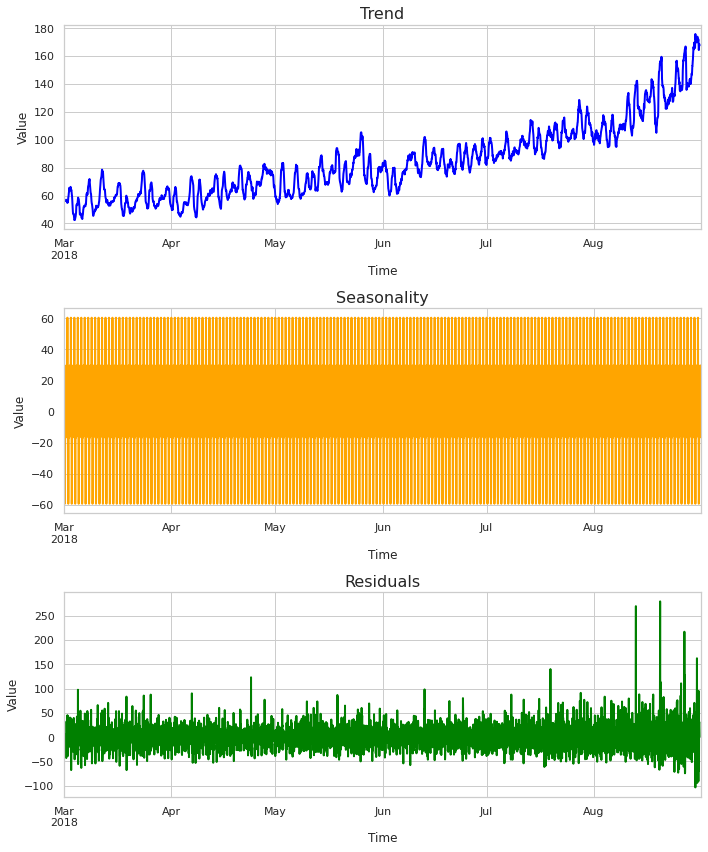

In [17]:
# Построить графики
plot_decomposition(decomposed)

- На графиках заметен тренд к росту заказов с течение времени. Кроме того, в тренде по прежнему заметная какая-то сезонность (колебания). Возможно в данных есть другие виды сезонности с более крупными периодами.
- Сезонность имеет либо очень маленький интервал, либо отсутствует вовсе. Необходимо увеличить масштаб.
- На графике шумов заметно, что в августе амплитуда шумов увеличивается. Шумы не объясняются сезонностью и трендом, а значит какие-то внешние факторы повлияли на перевозки таксистов в августе. Возможно это связано с началом сезона отпусков.

Учитывая то, что мы будем тестировать модель на последних 10% выборки, то модель может не распознать появление новых факторов (в периоде на котором она обучалась таких колебаний в шумах не было). Можно предположить, что метрика на тестовой выборке будет хуже чем на кросс-валидации при обучении модели.

Возможно этот фактор можно будет учесть, если рассматривать более широкий временной интервал (за пару лет) за счет годовой сезонности, но сейчас для этого нет достаточно данных.

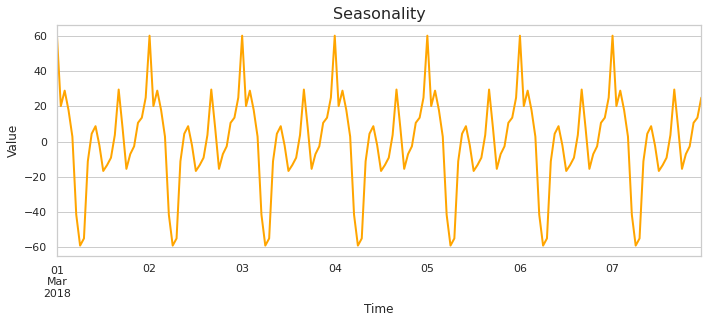

In [18]:
# посмотрим в приближении одной недели 
plot_decomposition(decomposed, time=('2018-03-01', '2018-03-07'), show_plots=[2])

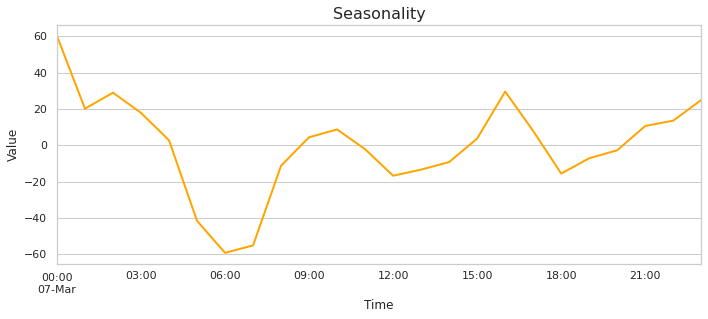

In [19]:
# посмотрим в приближении одного дня
plot_decomposition(decomposed, time=('2018-03-07', '2018-03-07'), show_plots=[2])

- Видна выраженная зависимость количества заказов от времени суток.
- Больше всего поездок совершается около полуночи, а меньше всего в 6 часов утра.

Посмотрим есть ли другие виды сезонностей, если изменить масштаба данных.

In [20]:
# сделаем ресемлинг с интервалом 1 день
df_day = taxi.resample('1D').sum()
decomposed_day = seasonal_decompose(df_day['num_orders'])

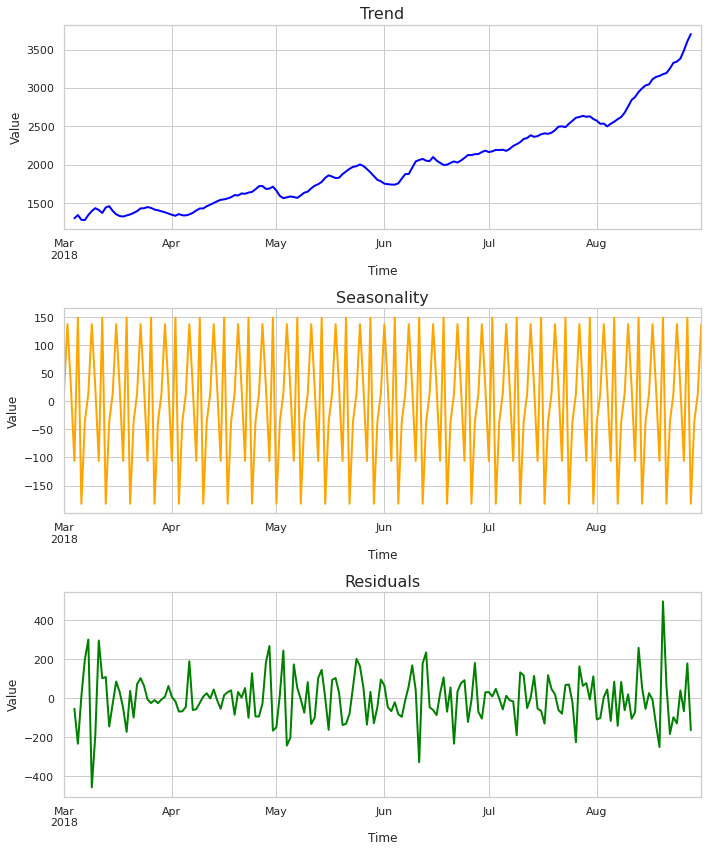

In [21]:
# посмотрим в приближении одного дня
plot_decomposition(decomposed_day)

- Тренд стал куда более плавным при ресемплинге по дням.
- На графике заметна сезонность с большим временным интервалом (вероятно недельный тренд). Нужно посмотреть внимательней в большем масштабе
- Шумы распределены равномерно.

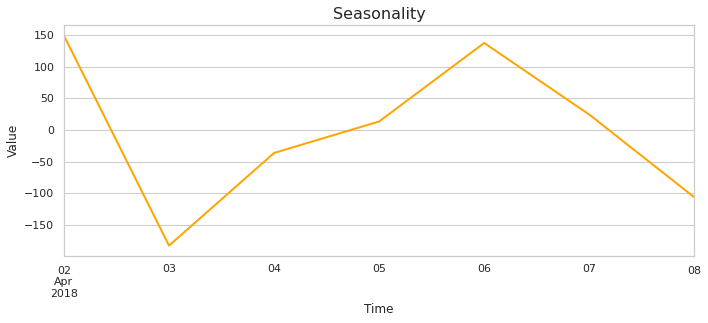

In [22]:
# посмотрим в приближении одной недели (с пн по вс)
plot_decomposition(decomposed_day, time=('2018-04-02', '2018-04-08'), show_plots=[2])

In [23]:
pd.date_range('2018-04-02', '2018-04-08').to_series().dt.day_name()

2018-04-02       Monday
2018-04-03      Tuesday
2018-04-04    Wednesday
2018-04-05     Thursday
2018-04-06       Friday
2018-04-07     Saturday
2018-04-08       Sunday
Freq: D, dtype: object

- Больше всего заказов совершается по понедельникам и по пятницам (конец и начало рабочей недели).
- Меньше всего во вторник.

Поскольку ряд с семплингом по 1 часу выглядит как нестационарный, попробуем проанализировать график разниц со сдвигом 1 час.

In [24]:
differences = pd.DataFrame(df['num_orders'].diff())
differences = differences.rename(columns={differences.columns[0]: 'differences'})

differences.head()

,differences
datetime,
2018-03-01 00:00:00,NaN
2018-03-01 01:00:00,-39.0
2018-03-01 02:00:00,-14.0
2018-03-01 03:00:00,-5.0
2018-03-01 04:00:00,-23.0


In [25]:
# добавим скользящее среднее за последние сутки
differences['rolling_mean'] = differences['differences'].rolling(24).mean()
differences['rolling_std'] = differences['differences'].rolling(24).std()

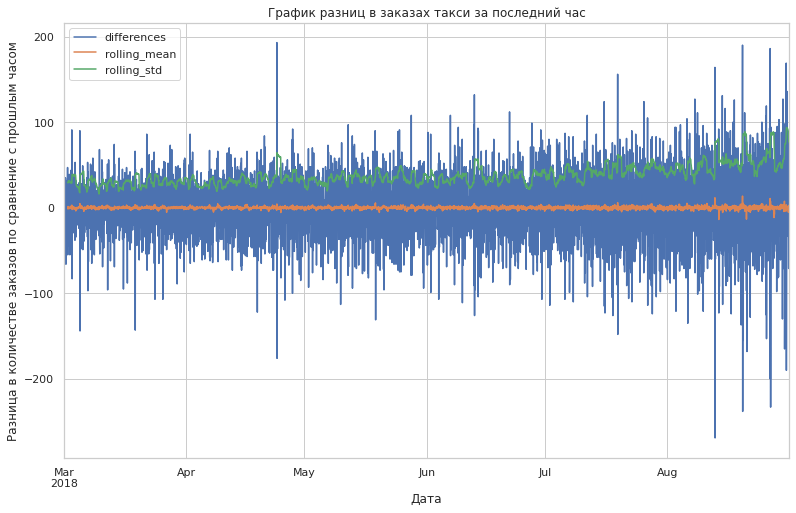

In [26]:
# построим график
differences.plot(figsize=(13,8))
plt.xlabel('Дата')
plt.ylabel('Разница в количестве заказов по сравнение с прошлым часом')
plt.title('График разниц в заказах такси за последний час')
plt.legend()
plt.show()

На графике видно, что ряд стал намного более стационарным: скользящие среднее и стандартное отклонение распределены более равномерно.

Если нам не удастся добиться удовлетворительного качества на модели с предсказанием количества заказов, то можно будет попробовать построить модель с прогнозом разницы в количестве заказов в следующем часе по сравнению с предыдущим. Тогда определить значение заказов в следующем часу можно будет прибавление предсказанной разницы к количеству фактических заказов за последний час.

## Обучение

### Подготовка данных

In [27]:
# заново создадим переменную без лишних колонок, созданных на этапе анализа
data = taxi.resample('1H').sum()
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [28]:
def make_features(data, max_lag, rolling_mean_size):
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    
    return data

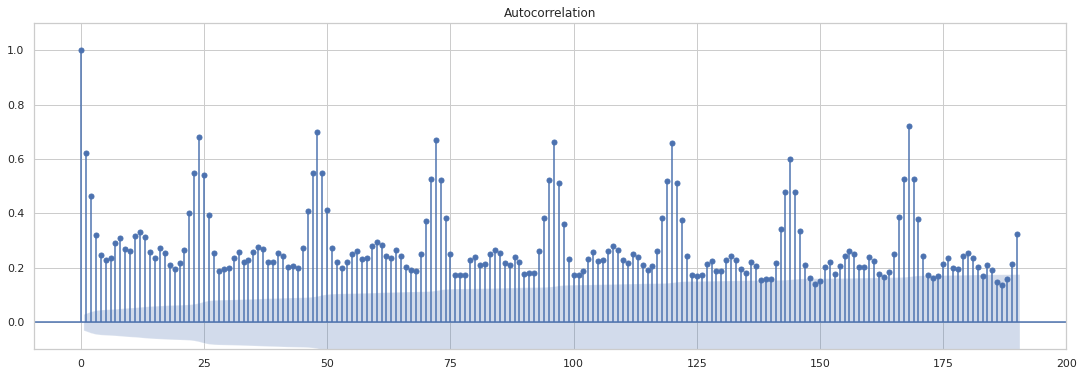

In [29]:
from statsmodels.graphics import tsaplots

taxi = pd.read_csv("/datasets/taxi.csv", index_col=[0], parse_dates=[0]).resample('1H').sum()
ts = taxi['num_orders']

fig = tsaplots.plot_acf(ts,lags= 190)
fig.set_size_inches(18.5, 6)
plt.ylim(-.1, 1.1)
plt.show() 

На графике автокорреляции лагов видно, что в районе 150-170 лага часть признаков перестает быть статистически значимой (ниже области синей заливки). Этот временной период как раз совпадает с одной неделью, на котором мы ранее смогли выявить начилие сезонности (рост числа заказов по понедельникам и пятницам).

Соответственно, чтобы наша модель учитывала сезонность и не переобучалась на статистически незначимых данных, в качестве порого для создания дополнительных признаков возьмем 1 неделю (168 лагов).

Скользящее среднее также возьмем за недельный период.

In [30]:
# создадим дополнительные признаки
make_features(data, 168, 168)
data.head()

,num_orders,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,1,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,1,3,1,124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,1,3,2,85.0,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,1,3,3,71.0,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,1,3,4,66.0,71.0,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
train, test = train_test_split(data, shuffle=False, test_size=TEST_SIZE)
train = train.dropna()

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

In [32]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3806, 172)
(3806,)
(442, 172)
(442,)


### Пайплайн

In [33]:
num_columns = list(X_train.columns)
num_columns

['day',
 'dayofweek',
 'hour',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'lag_8',
 'lag_9',
 'lag_10',
 'lag_11',
 'lag_12',
 'lag_13',
 'lag_14',
 'lag_15',
 'lag_16',
 'lag_17',
 'lag_18',
 'lag_19',
 'lag_20',
 'lag_21',
 'lag_22',
 'lag_23',
 'lag_24',
 'lag_25',
 'lag_26',
 'lag_27',
 'lag_28',
 'lag_29',
 'lag_30',
 'lag_31',
 'lag_32',
 'lag_33',
 'lag_34',
 'lag_35',
 'lag_36',
 'lag_37',
 'lag_38',
 'lag_39',
 'lag_40',
 'lag_41',
 'lag_42',
 'lag_43',
 'lag_44',
 'lag_45',
 'lag_46',
 'lag_47',
 'lag_48',
 'lag_49',
 'lag_50',
 'lag_51',
 'lag_52',
 'lag_53',
 'lag_54',
 'lag_55',
 'lag_56',
 'lag_57',
 'lag_58',
 'lag_59',
 'lag_60',
 'lag_61',
 'lag_62',
 'lag_63',
 'lag_64',
 'lag_65',
 'lag_66',
 'lag_67',
 'lag_68',
 'lag_69',
 'lag_70',
 'lag_71',
 'lag_72',
 'lag_73',
 'lag_74',
 'lag_75',
 'lag_76',
 'lag_77',
 'lag_78',
 'lag_79',
 'lag_80',
 'lag_81',
 'lag_82',
 'lag_83',
 'lag_84',
 'lag_85',
 'lag_86',
 'lag_87',
 'lag_88',
 'lag_89',

In [34]:
# Пайплайн предобработки
data_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough'
)

In [35]:
# Итоговый пайплайн
final_pipe = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

### Обучение моделей регрессии

Рассмотрим 4 базовые модели регрессии:
- LinearRegression
- DecisionTreeRegressor
- CatBoostRegressor
- LGBMRegressor

In [36]:
# Создадим списки для хранения названия паратров модели, метрики, времени обучения и времени предсказания:

models = []

**LinearRegression**

In [37]:
def find_best_model(pipe, param_grid, X_train, y_train, scoring, search_type='grid', cv=3, n_jobs=-1, n_iter=10, ts_split=False):
    # 1. Инициализация GridSearchCV или RandomizedSearchCV
    if search_type == 'grid':
        search = GridSearchCV(
            pipe,
            param_grid,
            cv=TimeSeriesSplit(n_splits=cv).split(X_train) if ts_split else cv,
            scoring=scoring,
            n_jobs=n_jobs
        )
    elif search_type == 'random':
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grid,
            n_iter=n_iter,
            cv=TimeSeriesSplit(n_splits=cv).split(X_train) if ts_split else cv,
            scoring=scoring,
            n_jobs=n_jobs
        )
    else:
        raise ValueError("search_type должен быть 'grid' или 'random'.")

    # 2. Обучение модели на тренировочных данных
    search.fit(X_train, y_train)

    # 3. Сохранение результатов поиска  
    model = search.best_estimator_
    score = abs(search.best_score_)
    results = pd.DataFrame(search.cv_results_)

    # 4. Вывод информации о лучшей модели и её параметрах
    print('Лучшая модель и её параметры:')
    print(model)

    # 5. Вывод лучшей метрики на кросс-валидации
    print('Лучшая метрика на кросс-валидации для лучшей модели:', score)

    # 6. Вывод результатов поиска
    relevant_columns = ['param_models', 'mean_fit_time', 'mean_score_time', 'params', 'mean_test_score']
    results = results[relevant_columns].sort_values(by='mean_test_score', ascending=False)
    

    return search, results, score

In [38]:
# Настраиваем сетку для перебора параметров
param_grid_linear = [
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']        
    }
]

In [39]:
gs_lin, results_lin, score_lin = find_best_model(
    final_pipe,
    param_grid_linear,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    search_type='grid',
    ts_split=True
)

Лучшая модель и её параметры:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['day', 'dayofweek', 'hour',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_4', 'lag_5', 'lag_6',
                                                   'lag_7', 'lag_8', 'lag_9',
                                                   'lag_10', 'lag_11', 'lag_12',
                                                   'lag_13', 'lag_14', 'lag_15',
                                                   'lag_16', 'lag_17', 'lag_18',
                                                   'lag_19', 'lag_20', 'lag_21',
                                                   'lag_22', 'lag_23', 'lag_24',
                                                   'lag_25', 'lag_26', 'lag_27', ...])]

In [40]:
results_lin

,param_models,mean_fit_time,mean_score_time,params,mean_test_score
2,LinearRegression(),0.438469,0.080288,"{'models': LinearRegression(), 'preprocessor__num': 'passthrough'}",-22.552020
0,LinearRegression(),0.361615,0.080240,"{'models': LinearRegression(), 'preprocessor__num': StandardScaler()}",-22.666665
1,LinearRegression(),0.396854,0.099154,"{'models': LinearRegression(), 'preprocessor__num': MinMaxScaler()}",-22.690599


Как видим в таблице, масштабирование практические не влияет на качество предсказаний модели - данные находятся примерно в одном диапазоне. Модель без масштабирования даже показала себя чуть лучше.

In [41]:
models.append(gs_lin.best_estimator_)

**DecisionTreeRegressor**

In [42]:
param_grid_tree = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(1, 31),
        'models__min_samples_split': range(2, 21),
        'models__min_samples_leaf': range(1, 21)
    }
]

In [43]:
gs_tree, results_tree, score_tree = find_best_model(
    final_pipe,
    param_grid_tree,
    X_train,
    y_train,
    n_iter=100, # Ограничимся 100 итерациями 
    cv=5,
    scoring='neg_root_mean_squared_error',
    search_type='random',
    ts_split=True
)

Лучшая модель и её параметры:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['day', 'dayofweek', 'hour',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_4', 'lag_5', 'lag_6',
                                                   'lag_7', 'lag_8', 'lag_9',
                                                   'lag_10', 'lag_11', 'lag_12',
                                                   'lag_13', 'lag_14', 'lag_15',
                                                   'lag_16', 'lag_17', 'lag_18',
                                                   'lag_19', 'lag_20', 'lag_21',
                                                   'lag_22', 'lag_23', 'lag_24',
                                                   'lag_25', 'lag_26', 'lag_27', ...

In [44]:
results_tree

,param_models,mean_fit_time,mean_score_time,params,mean_test_score
14,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.084928,0.005392,"{'models__min_samples_split': 11, 'models__min_samples_leaf': 20, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-26.515969
65,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.108691,0.005781,"{'models__min_samples_split': 19, 'models__min_samples_leaf': 5, 'models__max_depth': 5, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-26.593509
19,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.103475,0.005481,"{'models__min_samples_split': 7, 'models__min_samples_leaf': 8, 'models__max_depth': 5, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-26.606998
70,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.088617,0.005540,"{'models__min_samples_split': 12, 'models__min_samples_leaf': 8, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-26.657859
95,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.088314,0.005836,"{'models__min_samples_split': 10, 'models__min_samples_leaf': 7, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-26.669552
...,...,...,...,...,...
97,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.219124,0.005552,"{'models__min_samples_split': 12, 'models__min_samples_leaf': 1, 'models__max_depth': 22, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-33.017707
46,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.229342,0.005769,"{'models__min_samples_split': 9, 'models__min_samples_leaf': 1, 'models__max_depth': 28, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-33.344043
63,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.232644,0.005736,"{'models__min_samples_split': 8, 'models__min_samples_leaf': 1, 'models__max_depth': 30, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-33.682625
96,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.240716,0.005622,"{'models__min_samples_split': 5, 'models__min_samples_leaf': 1, 'models__max_depth': 27, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",-34.060283


In [45]:
models.append(gs_tree.best_estimator_)

**CatBoostRegressor**

In [46]:
param_grid_catboost = [
    {
        'models': [CatBoostRegressor(random_seed=RANDOM_STATE, verbose=0)]
    }
]

In [47]:
gs_cat, results_cat, score_cat = find_best_model(
    final_pipe,
    param_grid_catboost,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    search_type='grid',
    ts_split=True
)

Лучшая модель и её параметры:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['day', 'dayofweek', 'hour',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_4', 'lag_5', 'lag_6',
                                                   'lag_7', 'lag_8', 'lag_9',
                                                   'lag_10', 'lag_11', 'lag_12',
                                                   'lag_13', 'lag_14', 'lag_15',
                                                   'lag_16', 'lag_17', 'lag_18',
                                                   'lag_19', 'lag_20', 'lag_21',
                                                   'lag_22', 'lag_23', 'lag_24',
                                                   'lag_25', 'lag_26', 'lag_27', ...

In [48]:
results_cat

,param_models,mean_fit_time,mean_score_time,params,mean_test_score
0,<catboost.core.CatBoostRegressor object at 0x7fd63e2bc5e0>,29.108007,0.008112,{'models': <catboost.core.CatBoostRegressor object at 0x7fd63e2bc5e0>},-22.581411


In [49]:
models.append(gs_cat.best_estimator_)

**LGBMRegressor**

In [50]:
param_grid_lgbm = [
    {
        'models': [LGBMRegressor(random_state=RANDOM_STATE)],
        'models__n_estimators': [100, 300],
        'models__learning_rate' : [0.1, 0.2]
    }
]

In [51]:
gs_lgbm, results_lgbm, score_lgbm = find_best_model(
    final_pipe,
    param_grid_lgbm,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    search_type='grid',
    ts_split=True
)

Лучшая модель и её параметры:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['day', 'dayofweek', 'hour',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_4', 'lag_5', 'lag_6',
                                                   'lag_7', 'lag_8', 'lag_9',
                                                   'lag_10', 'lag_11', 'lag_12',
                                                   'lag_13', 'lag_14', 'lag_15',
                                                   'lag_16', 'lag_17', 'lag_18',
                                                   'lag_19', 'lag_20', 'lag_21',
                                                   'lag_22', 'lag_23', 'lag_24',
                                                   'lag_25', 'lag_26', 'lag_27', ...

In [52]:
results_lgbm

,param_models,mean_fit_time,mean_score_time,params,mean_test_score
0,LGBMRegressor(random_state=42),3.737315,0.027686,"{'models': LGBMRegressor(random_state=42), 'models__learning_rate': 0.1, 'models__n_estimators': 100}",-23.441326
1,LGBMRegressor(random_state=42),13.143729,0.042948,"{'models': LGBMRegressor(random_state=42), 'models__learning_rate': 0.1, 'models__n_estimators': 300}",-23.523939
2,LGBMRegressor(random_state=42),3.837166,0.060228,"{'models': LGBMRegressor(random_state=42), 'models__learning_rate': 0.2, 'models__n_estimators': 100}",-23.697300
3,LGBMRegressor(random_state=42),12.931848,0.026423,"{'models': LGBMRegressor(random_state=42), 'models__learning_rate': 0.2, 'models__n_estimators': 300}",-23.765988


In [53]:
models.append(gs_lgbm.best_estimator_)

**Примитивные модели**

In [54]:
# Прогноз константой (медианой)
median_value = y_train.median()
pred_median = np.ones(y_test.shape) * median_value


# Расчет RMSE
rmse_const = np.sqrt(mean_squared_error(y_test, pred_median))
print("RMSE:", rmse_const)

RMSE: 86.41465855206327


In [55]:
# Прогноз предыдущим значением
pred_previous = y_test.shift(1)
pred_previous.iloc[0] = y_train.iloc[-1]

# Расчет RMSE
rmse_prev = np.sqrt(mean_squared_error(y_test, pred_previous))
print("RMSE:", rmse_prev)

RMSE: 58.856486242815066


### Выбор лучшей модели

In [56]:
# Объяединим результаты в одну таблицу, отсортируем по убыванию и выведем лучший результат для каждой модели
scores_table = pd.concat([results_lin, results_tree, results_cat, results_lgbm], ignore_index=True)
scores_table['param_models'] = scores_table['param_models'].astype('str')
scores_table = scores_table.sort_values(by='mean_test_score', ascending=False)
scores_table = scores_table.drop_duplicates('param_models')
scores_table['mean_test_score'] = abs(scores_table['mean_test_score'])

In [57]:
scores_table

,param_models,mean_fit_time,mean_score_time,params,mean_test_score
0,LinearRegression(),0.438469,0.080288,"{'models': LinearRegression(), 'preprocessor__num': 'passthrough'}",22.552020
103,<catboost.core.CatBoostRegressor object at 0x7fd63e2bc5e0>,29.108007,0.008112,{'models': <catboost.core.CatBoostRegressor object at 0x7fd63e2bc5e0>},22.581411
104,LGBMRegressor(random_state=42),3.737315,0.027686,"{'models': LGBMRegressor(random_state=42), 'models__learning_rate': 0.1, 'models__n_estimators': 100}",23.441326
3,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.084928,0.005392,"{'models__min_samples_split': 11, 'models__min_samples_leaf': 20, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",26.515969


In [58]:
# функция для расчета общей оценки на основе присвоенных весов
def calculate_total_score(df, weights):
    # инициализация скейлера
    scaler = MinMaxScaler()

    # нормализация значений
    df[['mean_test_score_normalized', 'mean_fit_time_normalized', 'mean_score_time_normalized']] = scaler.fit_transform(df[['mean_test_score', 'mean_fit_time', 'mean_score_time']].values)

    # инвертирование нормализованных значений
    df['mean_test_score_normalized'] = 1 - df['mean_test_score_normalized']
    df['mean_fit_time_normalized'] = 1 - df['mean_fit_time_normalized']
    df['mean_score_time_normalized'] = 1 - df['mean_score_time_normalized']
    
    # расчет общей оценки с использованием нормализованных значений
    df['total_score'] = (
        df['mean_test_score_normalized'] * weights['score_weight'] +
        df['mean_fit_time_normalized'] * weights['time_fit_weight'] +
        df['mean_score_time_normalized'] * weights['time_pred_weight']
    ) * 100
    
    # округление total_score до 2 знаков после запятой
    df['total_score'] = df['total_score'].round(2)

    # удаление лишних колонок с нормализованными значениями
    df = df.drop(columns=['mean_test_score_normalized', 'mean_fit_time_normalized', 'mean_score_time_normalized'])

    return df

In [59]:
# Установка весов (сумма весов должна быть равна 1)
weights = {
    'score_weight': 0.90,       # 90% веса
    'time_fit_weight': 0.05,    # 5% веса
    'time_pred_weight': 0.05     # 5% веса
}

# Применение функции для расчета итогового скоринга
scores_table_final = calculate_total_score(scores_table, weights)

# Сортировка моделей по Total_Score (чем выше балл, тем лучше модель)
scores_table_final = scores_table_final.sort_values(by='total_score', ascending=False)
scores_table_final

,param_models,mean_fit_time,mean_score_time,params,mean_test_score,total_score
0,LinearRegression(),0.438469,0.080288,"{'models': LinearRegression(), 'preprocessor__num': 'passthrough'}",22.552020,94.94
103,<catboost.core.CatBoostRegressor object at 0x7fd63e2bc5e0>,29.108007,0.008112,{'models': <catboost.core.CatBoostRegressor object at 0x7fd63e2bc5e0>},22.581411,94.15
104,LGBMRegressor(random_state=42),3.737315,0.027686,"{'models': LGBMRegressor(random_state=42), 'models__learning_rate': 0.1, 'models__n_estimators': 100}",23.441326,77.69
3,"DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11,\n random_state=42)",0.084928,0.005392,"{'models__min_samples_split': 11, 'models__min_samples_leaf': 20, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, min_samples_split=11, random_state=42)}",26.515969,10.00


- Одинаково хорошо показали себя LinearRegression и CatBoostRegressor, но линейная регрессия обучается намного-намного быстрее.
- У LGBMRegressor метрика RMSE немного хуже, но зато она обучается быстрей чем CatBoostRegressor.
- DecisionTreeRegressor обучается быстрей всего, но смысла с этого мало - качество модели самое плохое.
- В любом случае, метрики всех обученных моделей получились существенно лучше, чем примитивные модели предсказаний по медиане и предыдущему значению.

В качестве лучшей модели выберем модель линейной регрессии.

In [60]:
best_model = gs_lin.best_estimator_

## Тестирование

In [61]:
# сделаем предсказания на тестовой выборки
start = time()
y_test_pred = best_model.predict(X_test)
end = time()

delta_time = end - start
print(f'Время предсказания на тестовой выборке: {round(delta_time,2)} секунд')

Время предсказания на тестовой выборке: 0.0 секунд


In [62]:
# Расчет RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)

if rmse <= RMSE_THRESHOLD:
    print('Проверка пройдена!')
else:
    print('Ошибка слишком велика!!! Попробуйте улучшить модель')
print()

RMSE: 34.463494132784
Проверка пройдена!



Модель прошла проверку, но качество оценки на тестовой выборке существенно снизилась по сравнению с кросс-валидацией при обучении. 

Как отмечали ранее такое снижение качества было ожидаемо, т.к. на тестирование ушла часть датасета в которых временной ряд показывал нестационарность (ускорение тренда и непостоянство дисперсии в шумах). Тем не менее модель прошла проверку.

In [63]:
# посмотрим и сравним график тестовых данных с предсказаниями
compare_pred = pd.DataFrame({'y_test' : y_test, 'y_test_pred' : y_test_pred})

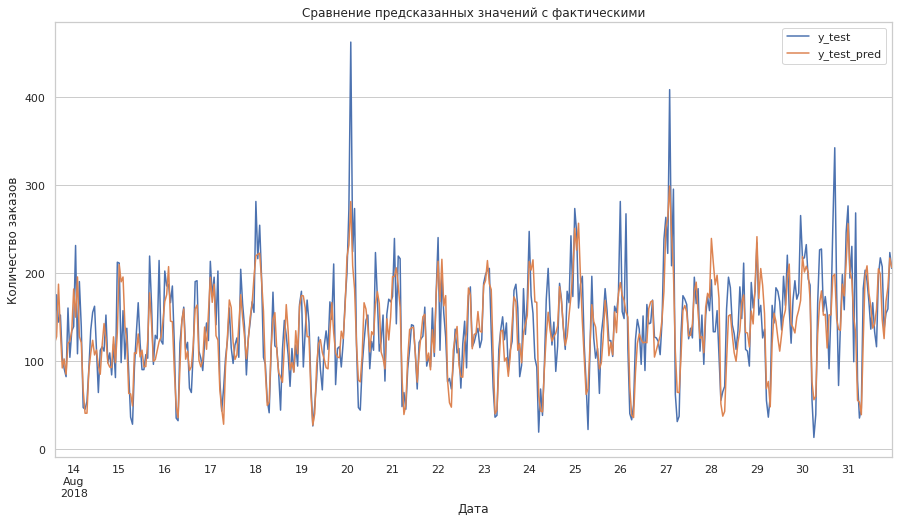

In [64]:
# построим график
compare_pred.plot(figsize=(15,8))
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('Сравнение предсказанных значений с фактическими')
plt.legend()
plt.show()

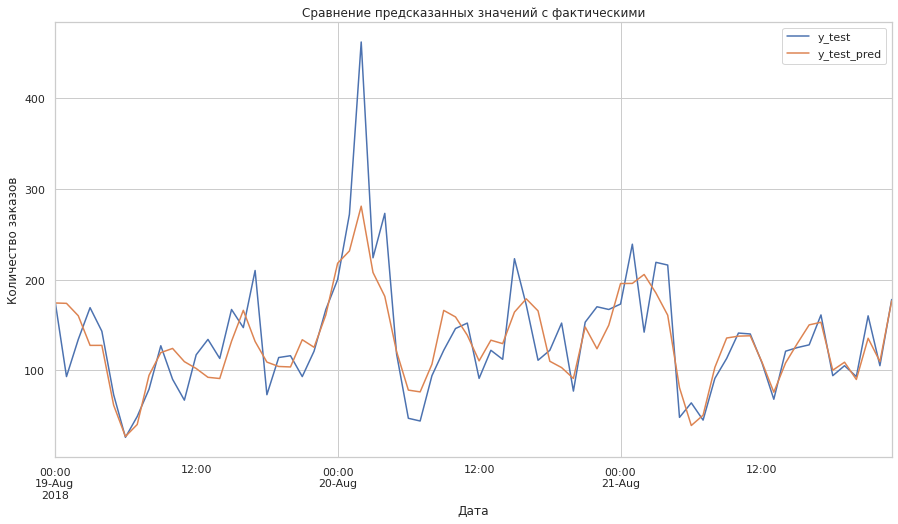

In [65]:
# построим график за 3 дня, там где видны выбросы
compare_pred['2018-08-19':'2018-08-21'].plot(figsize=(15,8))
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('Сравнение предсказанных значений с фактическими')
plt.legend()
plt.show()

На графиках видно, что модель в целом справилась очень хорошо с предсказаниями. Форма предсказанного графика очень близко повторяют график фактических поездок за исключением некоторых аномальных выбросов. 

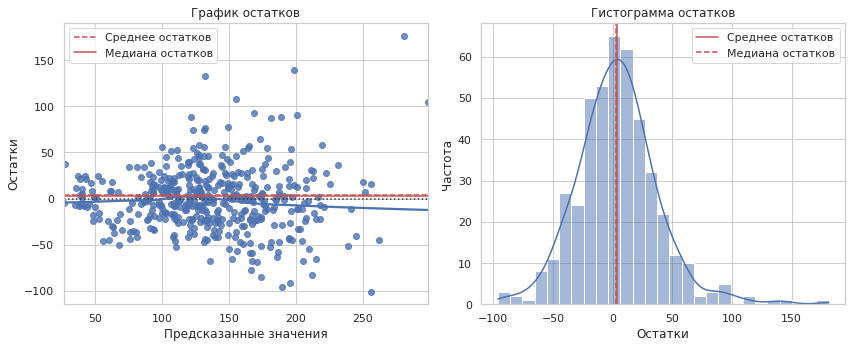

In [66]:
# посмотрим на распределение остатков модели
plot_residuals(y_test, y_test_pred)

**Анализ остатков:**
- На графике остатков нет явного паттерна, что может свидетельствовать о том, что модель адекватно описывает данные ( гетероскедастичность отсутствует). 
- Гистограмма остатков имеет вид нормального распределения с длинным правым хвостом. Это значит, что крупные ошибки модель чаще допускает в отрицательную сторону (то есть недооценивает количество заказов). 
- Среднее и медиана правктически совпадают друг с другом, однако виден их небольшой сдвиг в правую сторону. Т.е. модель в среднем чаще занижает количество заказов по сравнению с фактическими данными. Но сдвиг небольшой, в целом модель ведет себя адекватно.

In [67]:
print(f'Среднее значение остатков: {(y_test - y_test_pred).mean()}')
print(f'Медиана остатков: {(y_test - y_test_pred).median()}')

Среднее значение остатков: 3.9264977326632757
Медиана остатков: 2.513819261537634


В целом лучшая модель была выбрана и она прошла проверку на тестовых данных, исследовать другие модели не обязательно.

Но для интереса посмотрим, как бы справились другие модели.

In [68]:
for i in range(len(models)):
    print(f'{models[i]}:')
    model = models[i]
    
    predictions = model.predict(X_test)
    
    # Расчет RMSE
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print("RMSE:", rmse)

    if rmse <= RMSE_THRESHOLD:
        print('Проверка пройдена!')
    else:
        print('Ошибка слишком велика!!! Попробуйте улучшить модель')
    print()

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['day', 'dayofweek', 'hour',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_4', 'lag_5', 'lag_6',
                                                   'lag_7', 'lag_8', 'lag_9',
                                                   'lag_10', 'lag_11', 'lag_12',
                                                   'lag_13', 'lag_14', 'lag_15',
                                                   'lag_16', 'lag_17', 'lag_18',
                                                   'lag_19', 'lag_20', 'lag_21',
                                                   'lag_22', 'lag_23', 'lag_24',
                                                   'lag_25', 'lag_26', 'lag_27', ...])])),
                ('models',

Интересно, что все модели прошли проверку по качеству на обучаемых данных. 

Дерево решений справилось бы ожидаемо хуже других моделей, т.к. оно и показывало самые плохое качество на кросс-валидации.

Модели основанные на градиентном бустинге показали бы себя одинаково хорошо, но все равно хуже чем модель линейной регрессии.